# Logistic regression

## Importación de librerías y paquetes y definición de constantes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings


In [3]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [4]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Análisis descriptivo 

In [5]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [9]:
df.duplicated().sum()

np.int64(0)

### No hay duplicados pero nos aseguramos de borrarlos

In [10]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [12]:
df.isnull().sum().sort_values(ascending=False) / len(df)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

#### No hay valores nulos

### Limpieza de datos: Eliminar información irrelevante

In [26]:
corr_outcome = df.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
corr_outcome

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

#### No eliminamos ninguna variable porque pueden tener cierta influencia en la variable objetivo

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## Análisis de variables:

### Variables univariante: variables númericas

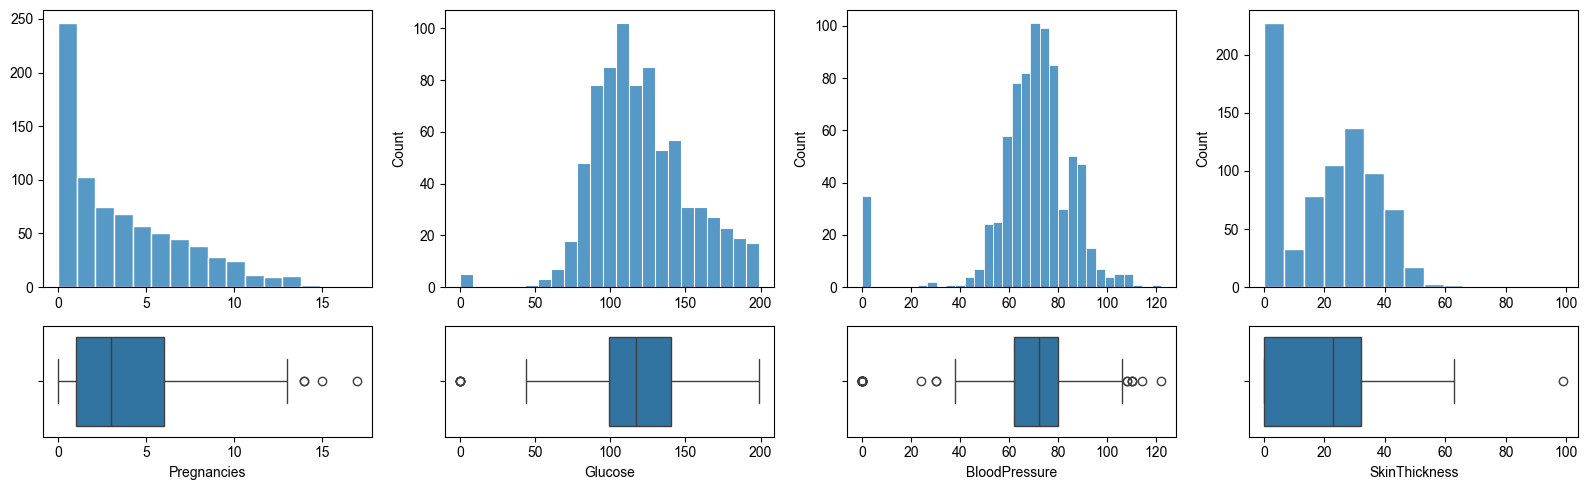

In [ ]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="Pregnancies").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="Pregnancies")
sns.histplot(ax=axis[0, 1], data=df, x="Glucose").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="Glucose")
sns.histplot(ax=axis[0, 2], data=df, x="BloodPressure").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="BloodPressure")
sns.histplot(ax=axis[0, 3], data=df, x="SkinThickness").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="SkinThickness")

plt.tight_layout()
plt.show()

In [20]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

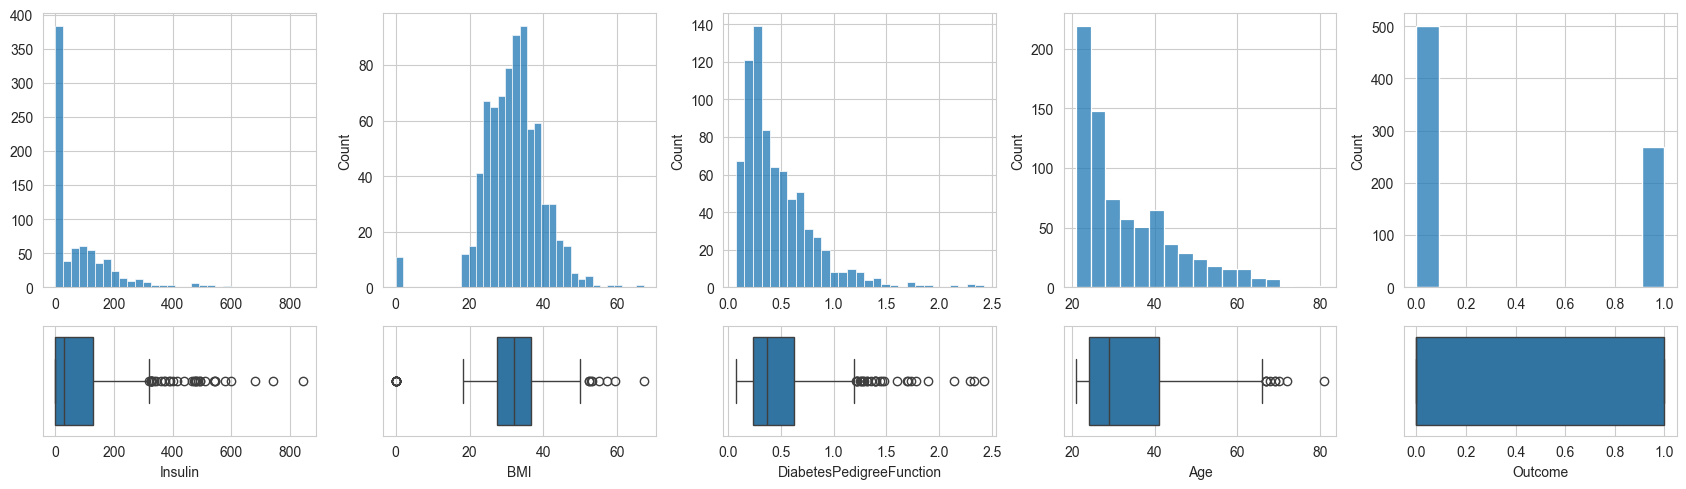

In [22]:
fig, axis = plt.subplots(2, 5, figsize=(17, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="Insulin").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="Insulin")
sns.histplot(ax=axis[0, 1], data=df, x="BMI").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="BMI")
sns.histplot(ax=axis[0, 2], data=df, x="DiabetesPedigreeFunction").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="DiabetesPedigreeFunction")
sns.histplot(ax=axis[0, 3], data=df, x="Age").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="Age")
sns.histplot(ax=axis[0, 4], data=df, x="Outcome").set(xlabel=None)
sns.boxplot(ax=axis[1, 4], data=df, x="Outcome")
plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos.
> - La variables siguen una distribución normalizada, sesgada hacia la izquierda en algunos casos

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

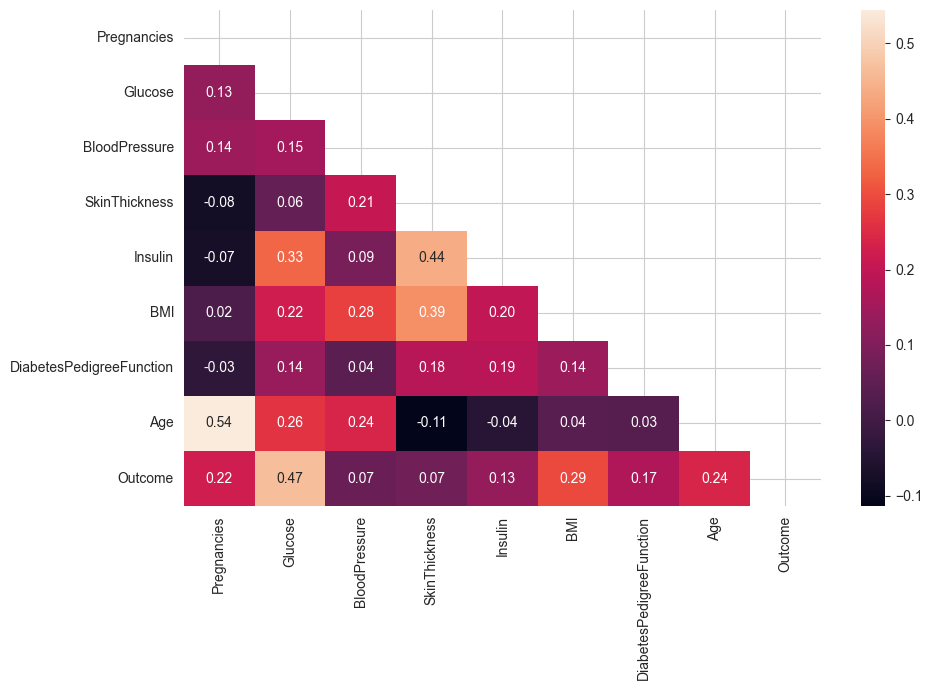

In [27]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

In [28]:
corr_outcome

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

### Observaciones:

Parece que todas las variables estan relacionadas de alguna u otra forma, procedemos a su estudio

#### Correlaciones con la variable objetivo

### Análisis de variables multivariante: númerico-númerico

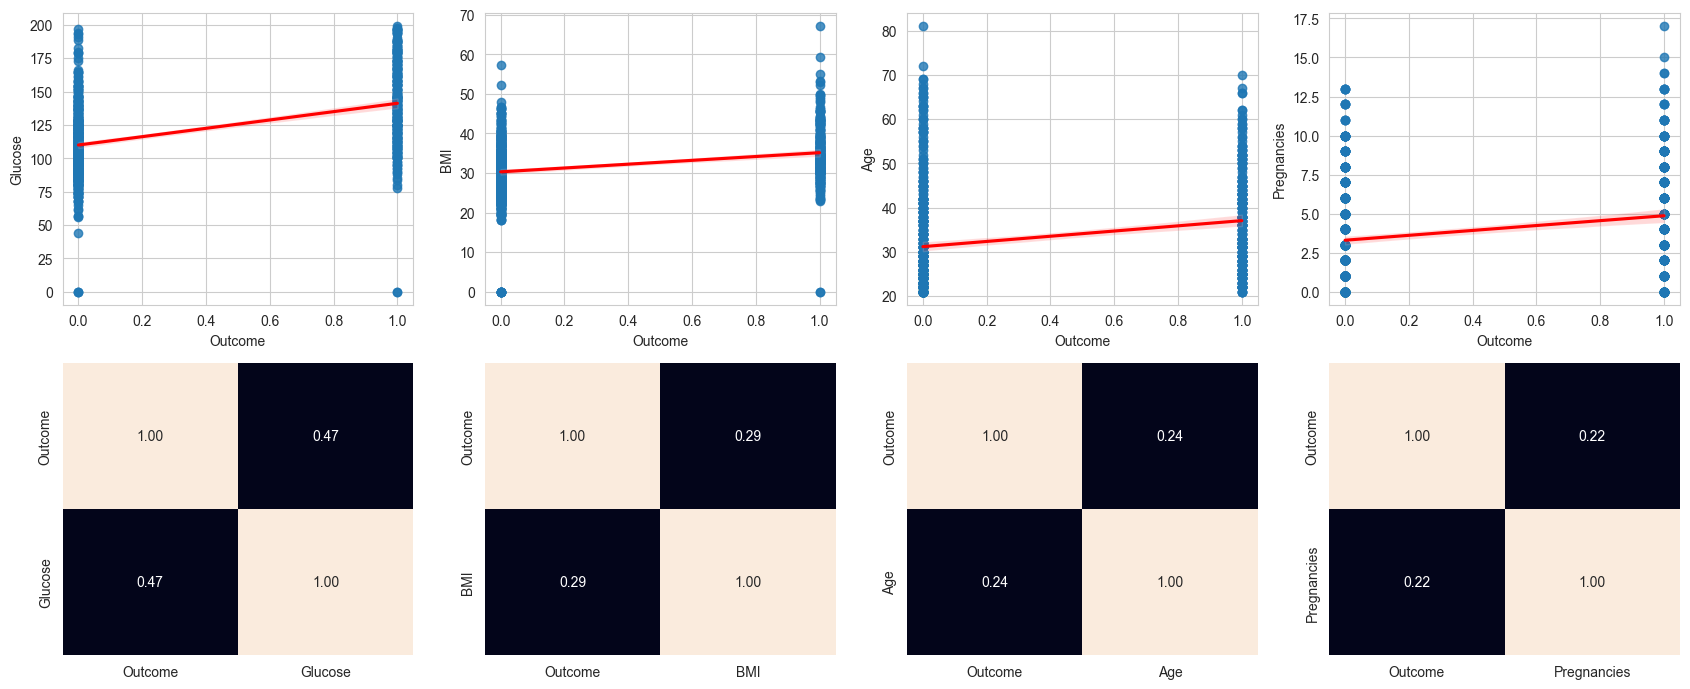

In [36]:
corr_out_glucose = df[["Outcome", "Glucose"]].corr()
corr_out_bmi = df[["Outcome", "BMI"]].corr()
corr_out_age = df[["Outcome", "Age"]].corr()
corr_out_pregnant = df[["Outcome", "Pregnancies"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="Outcome", y="Glucose", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_out_glucose, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="Outcome", y="BMI", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_out_bmi, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="Outcome", y="Age", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_out_age, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="Outcome", y="Pregnancies", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_out_pregnant, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

### Observaciones:

> - Podemos decir que hay linealidad entre las variables más relacionadas con 'Outcome'


#### Otras correlaciones interesantes entre variables:

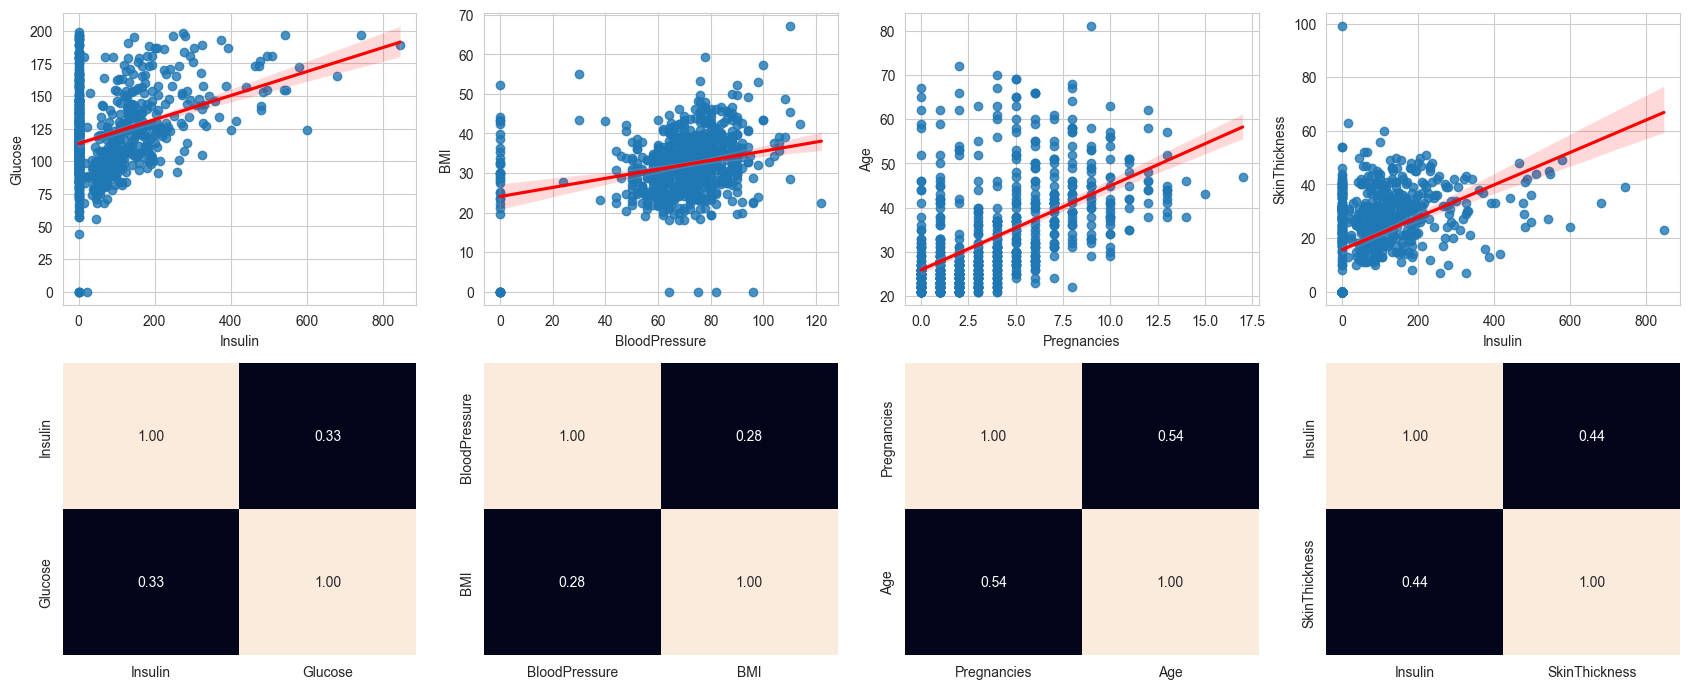

In [35]:
corr_insulin_glucose = df[["Insulin", "Glucose"]].corr()
corr_blood_bmi = df[["BloodPressure", "BMI"]].corr()
corr_pregnant_age = df[["Pregnancies", "Age"]].corr()
corr_insulin_skin = df[["Insulin", "SkinThickness"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="Insulin", y="Glucose", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_insulin_glucose, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="BloodPressure", y="BMI", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_blood_bmi, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="Pregnancies", y="Age", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_pregnant_age, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="Insulin", y="SkinThickness", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_insulin_skin, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

## Ingeniería de características

### Observaciones:

> - Podemos decir que hay linealidad entre las variables más relacionadas con 'Outcome'


### Análisis de outliers

#### Análisis descriptivo

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### Visualización

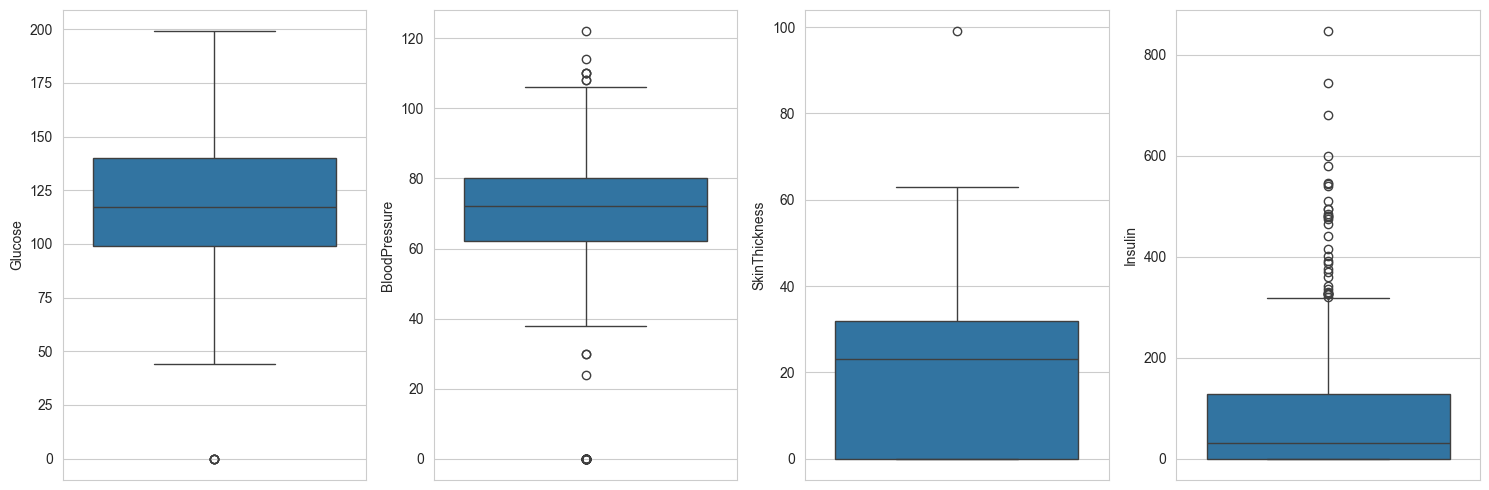

In [38]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="Glucose")
sns.boxplot(ax=axis[1], data=df, y="BloodPressure")
sns.boxplot(ax=axis[2], data=df, y="SkinThickness")
sns.boxplot(ax=axis[3], data=df, y="Insulin")
plt.tight_layout()
plt.show()

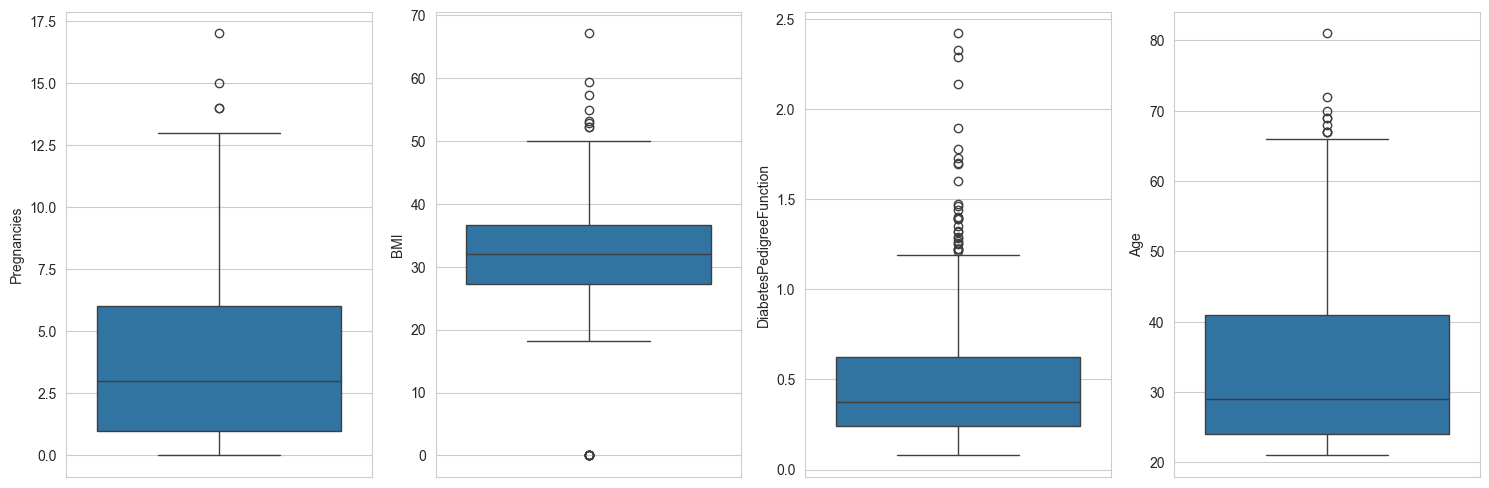

In [39]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="Pregnancies")
sns.boxplot(ax=axis[1], data=df, y="BMI")
sns.boxplot(ax=axis[2], data=df, y="DiabetesPedigreeFunction")
sns.boxplot(ax=axis[3], data=df, y="Age")
plt.tight_layout()
plt.show()

### Observaciones:

> - Observamos posibles valores "raros" en diferentes variables, posible sustitución: Eliminar datos, sustituir por la moda, sustituir por K-Nearest Neighbors


In [ ]:
imputer = KNNImputer(n_neighbors=5)
df[cols_con_ceros] = imputer.fit_transform(df[cols_con_ceros])

#### Valores atípicos 'age'

In [75]:
df['age'].describe()

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [76]:

q1_age = df["age"].quantile(0.25)
q3_age = df["age"].quantile(0.75)
iqr_age = q3_age - q1_age

# Definir los límites inferior y superior
lower_limit_age = 0 if (q1_age - 1.5 * iqr_age) < 0 else q1_age - 1.5 * iqr_age
upper_limit_age = q3_age + 1.5 * iqr_age

f"Límite superior: {round(upper_limit_age, 2)}, Límite inferior: {round(lower_limit_age, 2)}, Rango intercuartílico: {round(iqr_age, 2)}"

'Límite superior: 69.5, Límite inferior: 9.5, Rango intercuartílico: 15.0'

In [77]:
df[df['age'] > 70]

,age,job,default,housing,loan,campaign,previous,poutcome,y,job_n,default_n,housing_n,loan_n,y_n
27757,76,retired,no,no,yes,9,0,nonexistent,no,5,0,0,1,0
27780,73,retired,no,yes,no,1,1,failure,no,5,0,1,0,0
27800,88,retired,no,yes,no,1,0,nonexistent,no,5,0,1,0,0
27802,88,retired,no,no,no,2,0,nonexistent,yes,5,0,0,0,1
27805,88,retired,no,yes,yes,5,0,nonexistent,yes,5,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40986,84,retired,unknown,yes,yes,4,1,success,no,5,1,1,1,0
40996,81,retired,no,yes,no,1,2,failure,yes,5,0,1,0,1
41004,80,retired,no,yes,no,1,1,failure,yes,5,0,1,0,1
41183,73,retired,no,yes,no,1,0,nonexistent,yes,5,0,1,0,1


#### Considero que son valores atípicos normales en la distribución y decido mantenerlos

#### Valores atípicos 'campaign'

In [78]:
df['campaign'].describe()

count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [79]:
q1_campaign = df['campaign'].quantile(0.25)
q3_campaign = df['campaign'].quantile(0.75)
iqr_campaign = q3_campaign - q1_campaign

# Definir los límites inferior y superior
lower_limit_campaign = 0 if (q1_campaign - 1.5 * iqr_campaign) < 0 else q1_campaign - 1.5 * iqr_campaign
upper_limit_campaign = q3_campaign + 1.5 * iqr_campaign

f"Límite superior: {round(upper_limit_campaign, 2)}, Límite inferior: {round(lower_limit_campaign, 2)}, Rango intercuartílico: {round(iqr_campaign, 2)}"

'Límite superior: 6.0, Límite inferior: 0, Rango intercuartílico: 2.0'

In [80]:
df[df['campaign']>6]

,age,job,default,housing,loan,campaign,previous,poutcome,y,job_n,default_n,housing_n,loan_n,y_n
887,54,admin.,no,no,no,7,0,nonexistent,no,2,0,0,0,0
1043,41,technician,unknown,no,no,8,0,nonexistent,no,4,1,0,0,0
1094,40,technician,no,yes,no,8,0,nonexistent,no,4,0,1,0,0
1097,51,blue-collar,unknown,yes,no,7,0,nonexistent,no,3,1,1,0,0
1230,48,blue-collar,no,no,no,7,0,nonexistent,no,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40611,75,retired,no,no,no,9,1,failure,no,5,0,0,0,0
40631,88,retired,no,yes,no,7,0,nonexistent,no,5,0,1,0,0
40698,29,technician,no,yes,no,7,5,success,no,4,0,1,0,0
40821,33,technician,no,yes,no,9,2,failure,no,4,0,1,0,0


#### Considero que son valores normales y mantengo los outliers.

#### Valores atípicos 'previous'

In [81]:
df['previous'].describe().T

count    41176.000000
mean         0.173013
std          0.494964
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [82]:
q1_previous = df['previous'].quantile(0.25)
q3_previous = df['previous'].quantile(0.75)
iqr_previous = q3_previous - q1_previous

# Definir los límites inferior y superior
lower_limit_previous = 0 if (q1_previous - 1.5 * iqr_previous) < 0 else q1_previous - 1.5 * iqr_previous
upper_limit_previous = q3_previous + 1.5 * iqr_previous

f"Límite superior: {round(upper_limit_previous, 2)}, Límite inferior: {round(lower_limit_previous, 2)}, Rango intercuartílico: {round(iqr_previous, 2)}"

'Límite superior: 0.0, Límite inferior: 0.0, Rango intercuartílico: 0.0'

#### Hay una incongruencia matemática y cualquier valor se puede considerar atípico, sin embargo considero mantener la variable porque me parece interesante la influencia de campañas anteriores sobre la actual

#### Valores atípicos 'duration'

In [136]:
df['duration'].describe().T

count    41176.000000
mean       258.315815
std        259.305321
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [137]:
q1_duration = df['duration'].quantile(0.25)
q3_duration = df['duration'].quantile(0.75)
iqr_duration = q3_duration - q1_duration

# Definir los límites inferior y superior
lower_limit_duration = 0 if (q1_duration - 1.5 * iqr_duration) < 0 else q1_duration - 1.5 * iqr_duration
upper_limit_duration = q3_duration + 1.5 * iqr_duration

f"Límite superior: {round(upper_limit_duration, 2)}, Límite inferior: {round(lower_limit_duration, 2)}, Rango intercuartílico: {round(iqr_duration, 2)}"

'Límite superior: 644.5, Límite inferior: 0, Rango intercuartílico: 217.0'

#### Dado que la duración puede fluctuar hacia cualquier valor, decido mantener los valores atipicos

### Análisis de valores faltantes

In [139]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age           0.0
job           0.0
default       0.0
housing       0.0
loan          0.0
duration      0.0
campaign      0.0
previous      0.0
poutcome      0.0
y             0.0
job_n         0.0
default_n     0.0
housing_n     0.0
loan_n        0.0
y_n           0.0
poutcome_n    0.0
dtype: float64

#### En este caso no existen valores nulos debido a la limpieza de datos que hemos hecho previamente, así como tampoco es necesario hacer inferencia de características porque no tienen ninguna relación

## Split de datos

### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable 'y' como target y la codificamos en valores binarios

In [ ]:
X = df.drop(['y','y_n', 'job_n', 'default_n', 'housing_n',
             'loan_n', 'y_n', 'poutcome_n'], axis=1)
y = df['y_n']
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,age,job,default,housing,loan,duration,campaign,previous,poutcome
13521,49,admin.,no,no,no,105,1,0,nonexistent
18711,38,admin.,no,no,no,35,25,0,nonexistent
12887,36,admin.,no,yes,no,716,5,0,nonexistent
35835,35,technician,no,yes,no,394,1,0,nonexistent
27432,38,technician,no,yes,no,119,1,0,nonexistent
...,...,...,...,...,...,...,...,...,...
6501,33,self-employed,no,yes,yes,85,1,0,nonexistent
21640,54,technician,no,no,no,99,1,0,nonexistent
19862,52,blue-collar,no,no,no,809,1,0,nonexistent
14531,48,unemployed,no,yes,yes,200,3,0,nonexistent


## Scaling & Encoding

### Scaling

#### Usamos el método  standarscaler porque los datos están sesgados y hay valores atípicos

#### Scaling X_train

In [ ]:
standard_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import MinMaxScaler
num_variables = ['age', 'campaign', 'previous', 'duration']
standard_train_features = standard_scaler.fit_transform(X_train[num_variables])
X_train_standard = pd.DataFrame(standard_train_features,
                               index=X_train.index,
                               columns=num_variables)
X_train_standard

,age,campaign,previous,duration
13521,0.860817,-0.568738,-0.347629,-0.586966
18711,-0.194200,8.153988,-0.347629,-0.854900
12887,-0.386021,0.885050,-0.347629,1.751713
35835,-0.481932,-0.568738,-0.347629,0.519217
27432,-0.194200,-0.568738,-0.347629,-0.533380
...,...,...,...,...
6501,-0.673753,-0.568738,-0.347629,-0.663519
21640,1.340370,-0.568738,-0.347629,-0.609932
19862,1.148549,-0.568738,-0.347629,2.107682
14531,0.764906,0.158156,-0.347629,-0.223342


#### Scaling X_test

In [ ]:
standard_test_features = standard_scaler.transform(X_test[num_variables])
X_test_standard = pd.DataFrame(standard_test_features,
                               index=X_test.index,
                               columns=num_variables)
X_test_standard

,age,campaign,previous,duration
10574,0.860817,0.158156,-0.347629,-0.900832
19836,-0.769664,-0.568738,-0.347629,-0.414723
29499,1.340370,0.885050,-0.347629,-0.307550
36472,0.668996,-0.568738,-0.347629,-0.690312
18172,-0.002379,0.885050,-0.347629,-0.740071
...,...,...,...,...
14572,-0.865575,-0.568738,-0.347629,0.702943
16616,-0.098289,1.611943,-0.347629,-0.640553
30690,-0.577843,-0.568738,-0.347629,-0.583139
24409,-0.098289,-0.568738,-0.347629,0.568976


### Encoding

#### Usamos el método one-hot encoding ya que las variables a codificar no tienen un orden determinado

#### Encoding X_train

In [ ]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ['job', 'default', 'housing', 'loan', 'poutcome']
# Creamos la instancia del encoder
one_hot_encoder = OneHotEncoder(sparse_output=False)
# Entrenamos y aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = one_hot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_train_cat_ohe.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,poutcome_failure,poutcome_nonexistent,poutcome_success
13521,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
18711,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12887,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
35835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
27432,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


#### Encoding X_test

In [146]:
# Entrenamos y aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = one_hot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_test_cat_ohe.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,poutcome_failure,poutcome_nonexistent,poutcome_success
10574,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
19836,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
29499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
36472,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
18172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Guardado de scalers y encoders

In [147]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data-standard-scaler.pkl', 'wb') as file:
    pickle.dump(standard_scaler, file)

In [148]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data-one-hot-encoder.pkl', 'wb') as file2:
    pickle.dump(one_hot_encoder, file2)

## Módelo de regresión logística

### Inicialización y entrenamiento del modelo

In [149]:
X_train = pd.concat([X_train_standard, X_train_cat_ohe], axis=1)
X_test = pd.concat([X_test_standard, X_test_cat_ohe], axis=1)
X_train

,age,campaign,previous,duration,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,poutcome_failure,poutcome_nonexistent,poutcome_success
13521,0.860817,-0.568738,-0.347629,-0.586966,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
18711,-0.194200,8.153988,-0.347629,-0.854900,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12887,-0.386021,0.885050,-0.347629,1.751713,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
35835,-0.481932,-0.568738,-0.347629,0.519217,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
27432,-0.194200,-0.568738,-0.347629,-0.533380,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6501,-0.673753,-0.568738,-0.347629,-0.663519,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
21640,1.340370,-0.568738,-0.347629,-0.609932,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
19862,1.148549,-0.568738,-0.347629,2.107682,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
14531,0.764906,0.158156,-0.347629,-0.223342,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


#### Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)

In [150]:
model = LogisticRegression(random_state=24)
# Entrena
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,24
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Predicción del modelo

Una vez se ha entrenado el modelo, se puede utilizar para predecir con el conjunto de datos de prueba.

In [151]:
X_test.shape

(8236, 28)

In [152]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [153]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.9039582321515298

#### Matriz de confusión

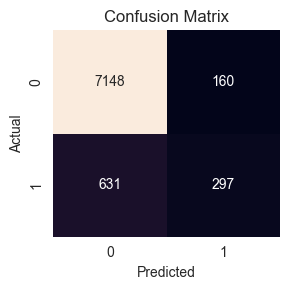

In [ ]:
bank_campaign_cm = confusion_matrix(y_test, y_pred)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(bank_campaign_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Optimización de resultados

In [156]:
hyperparams = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la cuadrícula
grid = GridSearchCV(model,
                    hyperparams,
                    scoring="accuracy",
                    cv=5)
grid

,estimator,LogisticRegre...ndom_state=24)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
grid.fit(X_train, y_train)
grid.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}

In [ ]:
best_model_grid = LogisticRegression(penalty='l2',
                                      C=1,
                                      solver='newton-cg')
best_model_grid.fit(X_train, y_train)
y_pred_grid = best_model_grid.predict(X_test)
grid_accuracy = accuracy_score(y_test, y_pred_grid)
model_accuracy, grid_accuracy

(0.9039582321515298, 0.9039582321515298)

#### Utilizando best_estimator directamente

In [159]:
grid.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,24
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
best_model_estimator = grid.best_estimator_
y_pred_estimator = best_model_estimator.predict(X_test)
best_estimator_accuracy = accuracy_score(y_test, y_pred_estimator)
model_accuracy, best_estimator_accuracy

(0.9039582321515298, 0.9039582321515298)

#### El ajuste de hiperparámetros con gridsearch no mejora el resultado 

#### Random search

In [161]:
# Definimos los parámetros que queremos ajustar
hyperparams = {'C': np.logspace(-4, 4, 20),
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model,
                                   hyperparams,
                                   n_iter=100,
                                   scoring="accuracy",
                                   cv=5,
                                   random_state=24)
random_search

,estimator,LogisticRegre...ndom_state=24)
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,100
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,24
,error_score,nan


In [ ]:
random_search.fit(X_train, y_train)
f"Mejores hiperparámetros: {random_search.best_params_}"

"Mejores hiperparámetros: {'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(0.23357214690901212)}"

In [164]:
model_random_search = LogisticRegression(penalty="l1",
                                         C=0.2335,
                                         solver="liblinear")

model_random_search.fit(X_train, y_train)
y_pred_random = model_random_search.predict(X_test)
random_search_accuracy = accuracy_score(y_test, y_pred_random)
random_search_accuracy

0.9040796503156873

#### El ajuste de hiperparámetros con randomsearch no tiene una mejora sustancial así que no lo tenemos en cuenta